

## Setup

In [ ]:

import os
# os.environ['RUST_LOG'] = "debug"
# os.environ['NO_COLOR'] = "1"
# os.environ['IMPALAB_SEED'] = "42"


In [ ]:
# from benchmarking import Impa

# impa = Impa(
#   root_dir="..", 
#   local_bin_dir='/media/Lean/lean/impalab/target/debug',
#   generator= 'somombo_unifshuffle_multi',

# )



# _build_result = impa.build(
#   # include=['somombo_unifshuffle', 'lean']
# )
# assert _build_result, "Initial build failed"


# impa.run_once(
#   tasks=[ 
#     {'executor': 'lean', 'args': ['Array.qsort']},
#     {'executor': 'lean', 'args': ['Somombo.qs.bentleyMcIlroy.classic']},
#   ],
#   gen_args=[
#     {
#       'cardinality': 4, 
#       'multiplicity': 3, 
#       'descending': True, 
#       'swaps': 1, 
#       'seed': '8554415485463349895',
#     },
#     {
#       'cardinality': 3, 
#       'multiplicity': 4, 
#       'descending': False, 
#       'swaps': None, 
#       'seed': '42',
#     }
#   ]
# )

In [ ]:
from benchmarking import Impa

impa = Impa(
  root_dir="..", 
  local_bin_dir='/media/Lean/lean/impalab/target/debug',
  generator= 'somombo_unifshuffle',
)

_build_result = impa.build(
  include=[
    'somombo_unifshuffle',
    'somombo_unifshuffle_multi',
    'lean', 
    'cpp',
  ]
)
assert _build_result, "Initial build failed"




impa.run_once(
  tasks=[ 
    # {'executor': 'lean', 'args': ['Array.qsort']},
    # {'executor': 'lean', 'args': ['List.mergeSort']},
    {'executor': 'cpp', 'args': ['std::sort']},
  ],
  **{
      'runs': 2, 
      'reps': 3, 
      'cardinality': 1_000, 
      'multiplicity': 1, 
      'descending': False, 
      'swaps': None, 
      'seed': '8554415485463349895',
    }
)

--- Building Components (Dir: /media/Lean/lean/__delete/impalab-sort-bench-dev) ---
--- Build Complete ---


[{'task_index': 0,
  'executor': 'cpp',
  'args': ['--functions=std::sort'],
  'data_id': '0_0_9522047150282041134',
  'duration': 111188},
 {'task_index': 0,
  'executor': 'cpp',
  'args': ['--functions=std::sort'],
  'data_id': '0_1_12783185464429488137',
  'duration': 103659},
 {'task_index': 0,
  'executor': 'cpp',
  'args': ['--functions=std::sort'],
  'data_id': '1_0_9522047150282041134',
  'duration': 111570},
 {'task_index': 0,
  'executor': 'cpp',
  'args': ['--functions=std::sort'],
  'data_id': '1_1_12783185464429488137',
  'duration': 100508},
 {'task_index': 0,
  'executor': 'cpp',
  'args': ['--functions=std::sort'],
  'data_id': '2_0_9522047150282041134',
  'duration': 125724},
 {'task_index': 0,
  'executor': 'cpp',
  'args': ['--functions=std::sort'],
  'data_id': '2_1_12783185464429488137',
  'duration': 152339}]

## Experiment Config

In [ ]:
from exploration import ExplorerFromResults

_test_results = impa.run(
  runs=4,
  reps=1,
  seed=42,
  tasks=[ 
    'lean Array.qsort',
    # 'lean Somombo.qs.bentleyMcIlroy.classic',
    "cpp std::sort",
  ],

  params_list=[
    {
      "cardinality": 7,
      "multiplicity": 11,
      "swaps": 1,
      "descending": True,
      "runs": 3,
      "reps": 1
    }, 
    {
      "cardinality": 3,
      "multiplicity": 4,
      "swaps": None,
      "descending": False,
      "runs": 1,
      "reps": 1
    }
  ],
)


testdf = ExplorerFromResults(_test_results, experiment_name="Warmup-Experiment").get_raw_data() 
display(_test_results)
testdf.head()

INFO: Run Seeds [2053695854357871005, 13679192365072849617, 4517457392071889495, 2574020394472462046]


Rep:   0%|          | 0/1 [00:00<?, ?it/s]

Run:   0%|          | 0/4 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/2 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/2 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/2 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/2 [00:00<?, ?it/s]

[{'task_index': 0,
  'executor': 'lean',
  'args': ['Array.qsort'],
  'data_id': '0_0_9337031989501815608',
  'duration': 32528,
  'macro_rep_id': '0',
  'macro_run_id': '0',
  'cardinality': 7,
  'multiplicity': 11,
  'swaps': 1,
  'descending': True,
  'runs': 3,
  'reps': 1,
  'seed': 2053695854357871005},
 {'task_index': 0,
  'executor': 'lean',
  'args': ['Array.qsort'],
  'data_id': '0_1_2265897958933201012',
  'duration': 34141,
  'macro_rep_id': '0',
  'macro_run_id': '0',
  'cardinality': 7,
  'multiplicity': 11,
  'swaps': 1,
  'descending': True,
  'runs': 3,
  'reps': 1,
  'seed': 2053695854357871005},
 {'task_index': 0,
  'executor': 'lean',
  'args': ['Array.qsort'],
  'data_id': '0_2_11711776084604228309',
  'duration': 37488,
  'macro_rep_id': '0',
  'macro_run_id': '0',
  'cardinality': 7,
  'multiplicity': 11,
  'swaps': 1,
  'descending': True,
  'runs': 3,
  'reps': 1,
  'seed': 2053695854357871005},
 {'task_index': 1,
  'executor': 'cpp',
  'args': ['--functions=st

,macro_rep_id,macro_run_id,micro_rep_id,micro_run_id,data_hash,executor,args,task_str,cardinality,multiplicity,swaps,descending,seed,duration,experiment_name
0,0,0,0,0,9337031989501815608,lean,[Array.qsort],lean Array.qsort,7,11,1,True,2053695854357871005,32528,Warmup-Experiment
1,0,0,0,1,2265897958933201012,lean,[Array.qsort],lean Array.qsort,7,11,1,True,2053695854357871005,34141,Warmup-Experiment
2,0,0,0,2,11711776084604228309,lean,[Array.qsort],lean Array.qsort,7,11,1,True,2053695854357871005,37488,Warmup-Experiment
3,0,0,0,0,9337031989501815608,cpp,[--functions=std::sort],cpp --functions=std::sort,7,11,1,True,2053695854357871005,2533,Warmup-Experiment
4,0,0,0,1,2265897958933201012,cpp,[--functions=std::sort],cpp --functions=std::sort,7,11,1,True,2053695854357871005,1661,Warmup-Experiment


In [5]:
from sample_factors import sample_spaced, get_factors, get_hcns

In [6]:
tasks = [ 

  # 'lean Array.qsort',
  'lean Somombo.qs.hoare.classic',
  # "cpp --functions=std::sort",

]

## Experiment 1: Cardinality (Pre-sorted in Ascending Order)

In [7]:
_cards = sample_spaced(
    5,
    start=1000,
    stop=2_000_000,
    geometric=True,
)
print("Geometric Progression of Cardinalities to test:", _cards)

params_list = [
    {"cardinality": card, "multiplicity": 1, "descending": False, 'swaps': None} for card in _cards
]
import pandas as pd
# params_list.reverse()
pd.DataFrame(params_list).style.hide(axis='index')

Geometric Progression of Cardinalities to test: [1000, 6687, 44721, 299070, 2000000]


cardinality,multiplicity,descending,swaps
1000,1,False,None
6687,1,False,None
44721,1,False,None
299070,1,False,None
2000000,1,False,None


### exp1

In [8]:
_results = impa.run(
  tasks=tasks,
  params_list=params_list,

  runs=50,
  micro_runs=1,
  reps=1,
  micro_reps=50, # x
)

exp1 = ExplorerFromResults(_results, experiment_name = "exp1")


INFO: Run Seeds [16843022230865928483, 10675552072015593955, 10014010079834795161, 12948697583026129128, 823584755331107448, 14345338218537163571, 10537474013703387984, 16903930297695479359, 10112517775565423490, 16178414030412471039, 12935364697562754731, 5701132289885661742, 18244903398124630613, 255911263418402651, 10779958067695289184, 5661714153216121078, 3950548714435563887, 12687338537752409727, 812916118846571694, 16705248624216901686, 12115107259110252987, 795487448543896585, 2747454012346281121, 15573789331959591410, 16900351489551975533, 12090947431609527557, 17147879451821019099, 8527076837345466575, 15229907644193437871, 2651040298391160852, 4436406136988244147, 11512222509316823217, 10191661369713888830, 9221835077233271815, 2884046582358949478, 10626328064523018726, 365873857389242240, 6137642089880622761, 4292997133747715927, 15235294655490012433, 1544081566098490676, 12521056154149176173, 1452549176862228601, 13346049280315743316, 4349389226493559622, 14576169513650195

Rep:   0%|          | 0/1 [00:00<?, ?it/s]

Run:   0%|          | 0/50 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

...

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

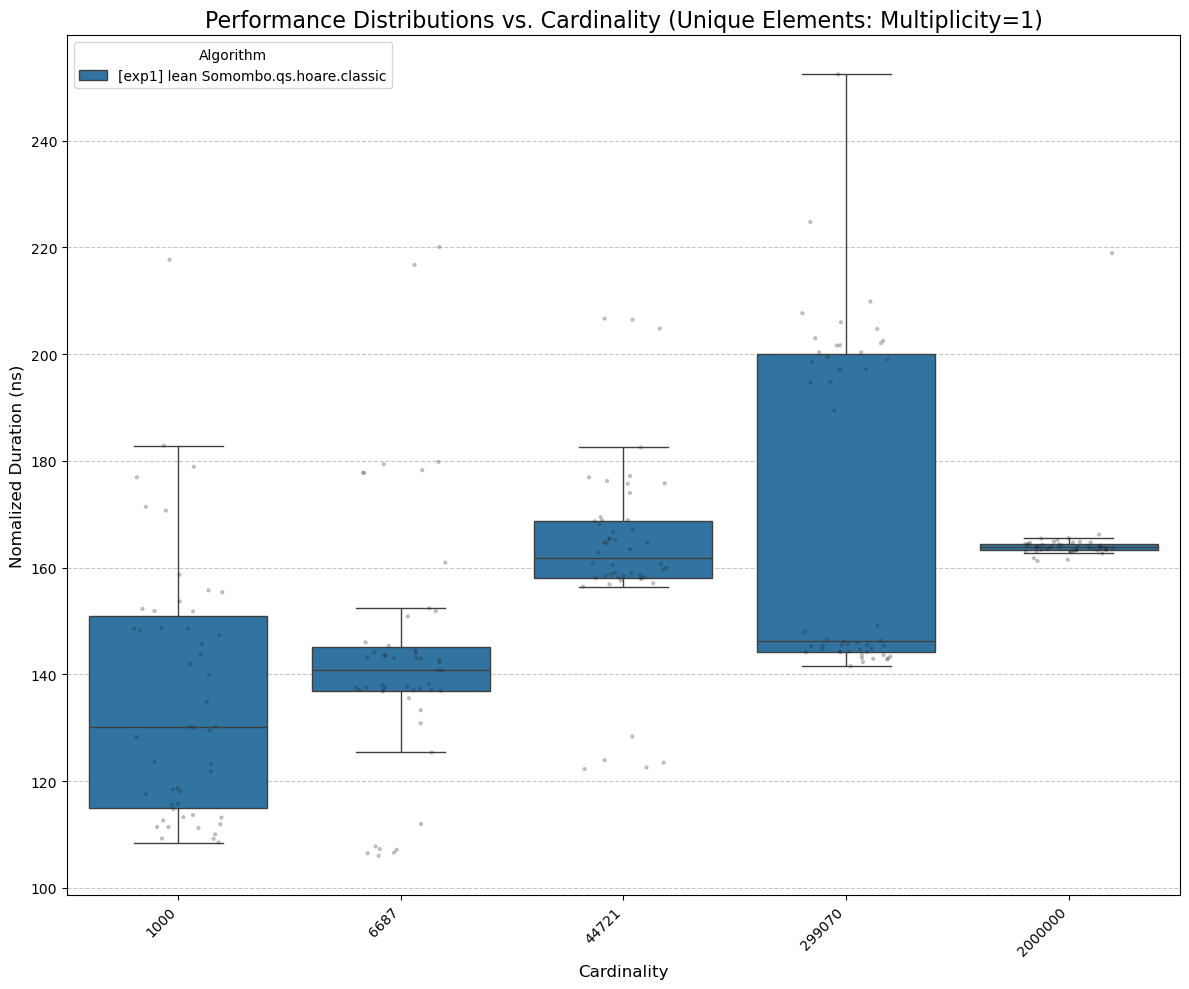

In [9]:
exp1.plot_distributions(
  'cardinality', 
  title=f'Performance Distributions vs. Cardinality (Unique Elements: Multiplicity=1)',
  normalized=True,
  ylog=False,
)

In [10]:
exp1.plot_trends_interactive(
    'cardinality', 
    f'Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1)',
    normalized=True,
    xlog=True,
    ylog=False,
)

--- Interactive Trend: Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1) ---


### exp2

In [11]:
_results = impa.run(
  tasks=tasks,
  params_list=params_list,

  runs=1,
  micro_runs=50,
  reps=50,
  micro_reps=1,

)

exp2 = ExplorerFromResults(_results, experiment_name = "exp2")


INFO: Run Seeds [3040256529020369739]


Rep:   0%|          | 0/50 [00:00<?, ?it/s]

Run:   0%|          | 0/1 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Run:   0%|          | 0/1 [00:00<?, ?it/s]

...

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Run:   0%|          | 0/1 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Run:   0%|          | 0/1 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

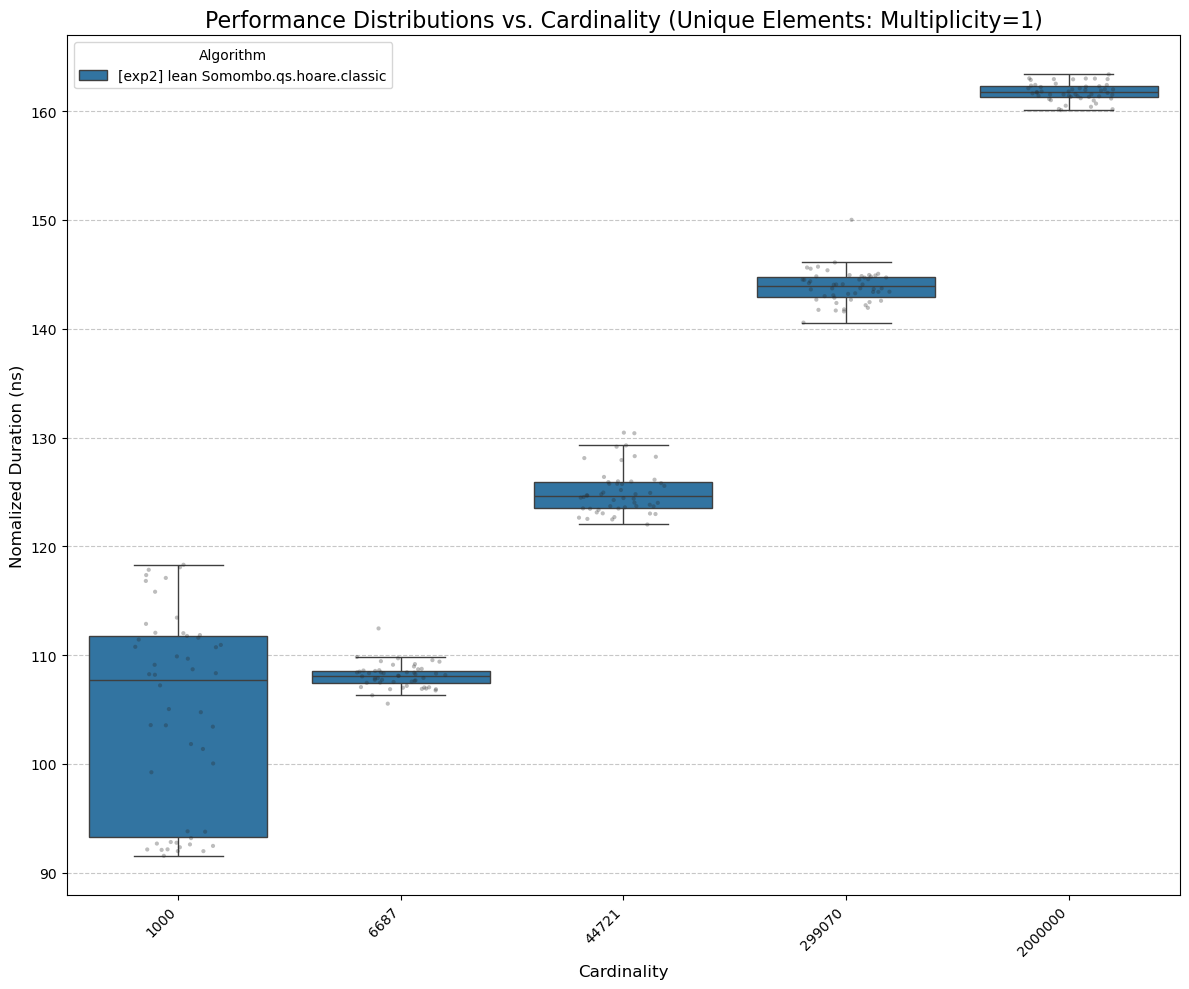

In [12]:
exp2.plot_distributions(
  'cardinality', 
  title=f'Performance Distributions vs. Cardinality (Unique Elements: Multiplicity=1)',
  normalized=True,
  ylog=False,
)

In [13]:
exp2.plot_trends_interactive(
    'cardinality', 
    f'Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1)',
    normalized=True,
    xlog=True,
    ylog=False,
)

--- Interactive Trend: Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1) ---


### exp3

In [14]:
_results = impa.run(
  tasks=tasks,
  params_list=params_list,

  runs=1,
  micro_runs=50,
  reps=1,
  micro_reps=50, # x

)

exp3 = ExplorerFromResults(_results, experiment_name = "exp3")


INFO: Run Seeds [10311875844086193796]


Rep:   0%|          | 0/1 [00:00<?, ?it/s]

Run:   0%|          | 0/1 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

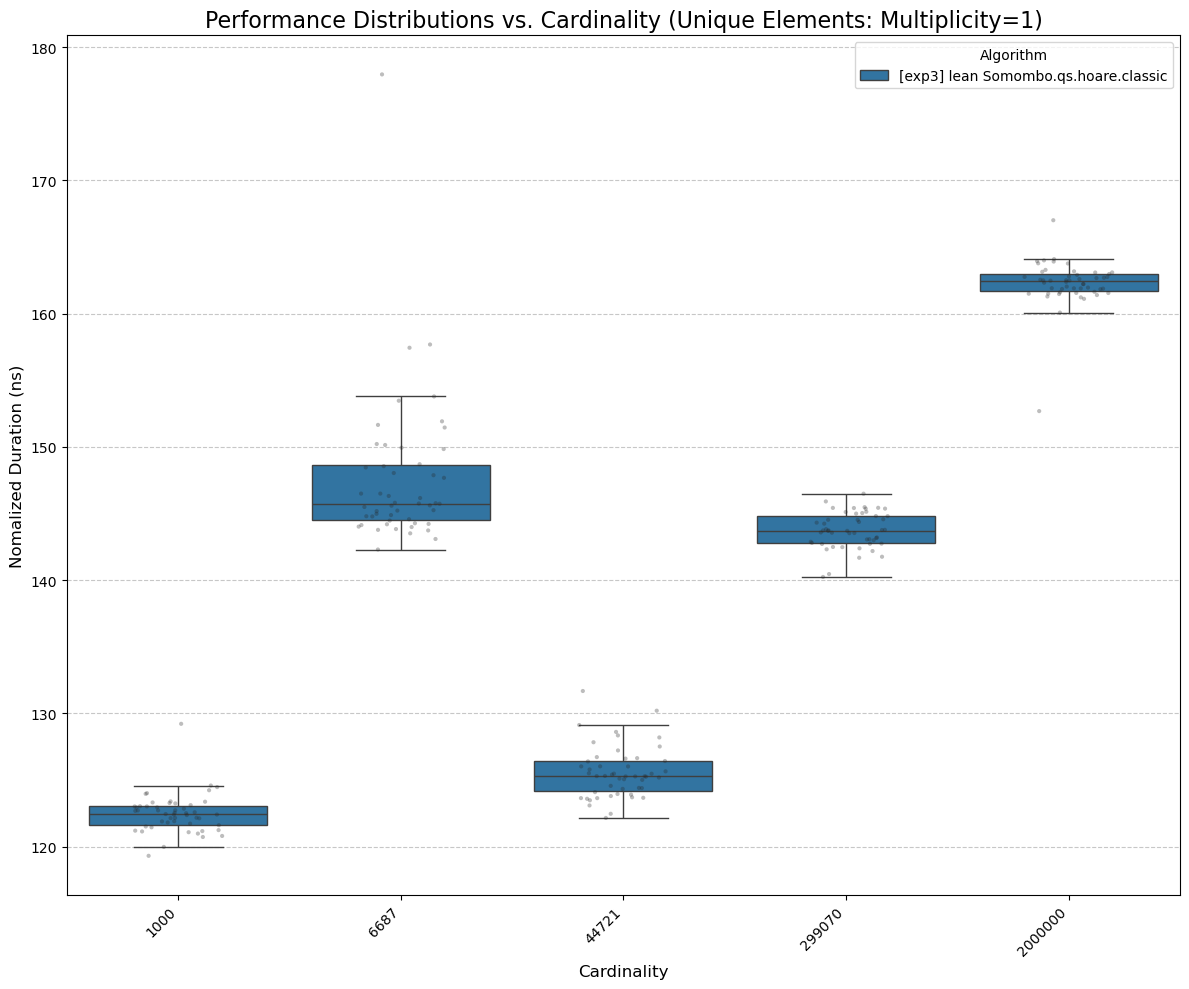

In [15]:
exp3.plot_distributions(
  'cardinality', 
  title=f'Performance Distributions vs. Cardinality (Unique Elements: Multiplicity=1)',
  normalized=True,
  ylog=False,
)

In [16]:
exp3.plot_trends_interactive(
    'cardinality', 
    f'Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1)',
    normalized=True,
    xlog=True,
    ylog=False,
)

--- Interactive Trend: Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1) ---


### exp4

In [17]:
_results = impa.run(
  tasks=tasks,
  params_list=params_list,

  runs=50,
  micro_runs=1,
  reps=50, #ok
  micro_reps=1,
)

exp4 = ExplorerFromResults(_results, experiment_name = "exp4")


INFO: Run Seeds [10231689480614983256, 17236231404189078495, 2421455913656091913, 11416916707214232255, 11594430405186051062, 17688137948176800734, 13646361562348259271, 18367720002165180664, 1511502450853086339, 268295718680109135, 16376612810123260221, 13019436498215321657, 3889511346684032596, 10341039932856019298, 3501120835034219466, 14895943616415168711, 7934656182753350308, 14455146529450631879, 5098198176567945024, 1274758322040588174, 6970570717255655334, 11956154294700134878, 3131766834456827619, 7538289838748222341, 1015101602003422248, 2690603339782764946, 2490520980752249130, 9159652866073688863, 4269337927245762801, 11992671169779417879, 5998110981344799812, 15568358504925770401, 9676961261129595389, 14549499276485821299, 12261296280098980101, 14442800718532814851, 15247089039587114699, 12271364538821276660, 11250782830435704203, 6227839563413683296, 3473869085254152793, 18034848407242631685, 17514564302587286492, 11466638147010220861, 15024660570117117198, 35469384658644

Rep:   0%|          | 0/50 [00:00<?, ?it/s]

Run:   0%|          | 0/50 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

...

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

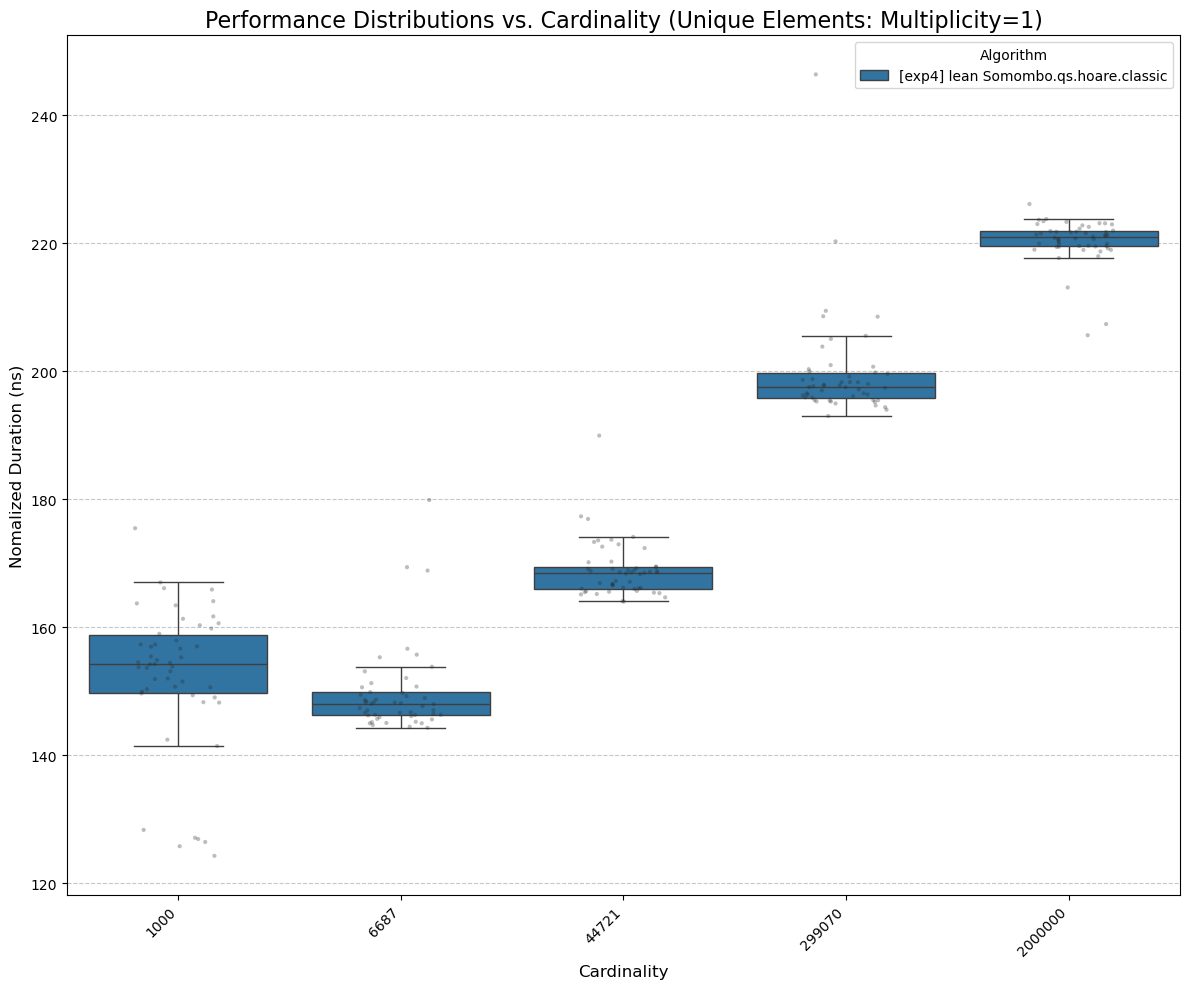

In [18]:
exp4.plot_distributions(
  'cardinality', 
  title=f'Performance Distributions vs. Cardinality (Unique Elements: Multiplicity=1)',
  normalized=True,
  ylog=False,
)

In [19]:
exp4.plot_trends_interactive(
    'cardinality', 
    f'Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1)',
    normalized=True,
    xlog=True,
    ylog=False,
)

--- Interactive Trend: Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1) ---


### extra

In [20]:
_results = impa.run(
  tasks=tasks,
  params_list=params_list,

  runs=5,
  micro_runs=5,
  reps=5,
  micro_reps=5,
)

exp5 = ExplorerFromResults(_results, experiment_name = "exp5")


INFO: Run Seeds [10525064407430987579, 6724395897433245054, 14008791269045354470, 17690259760022886682, 16007877220581075977]


Rep:   0%|          | 0/5 [00:00<?, ?it/s]

Run:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

...

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

Gen Param:   0%|          | 0/5 [00:00<?, ?it/s]

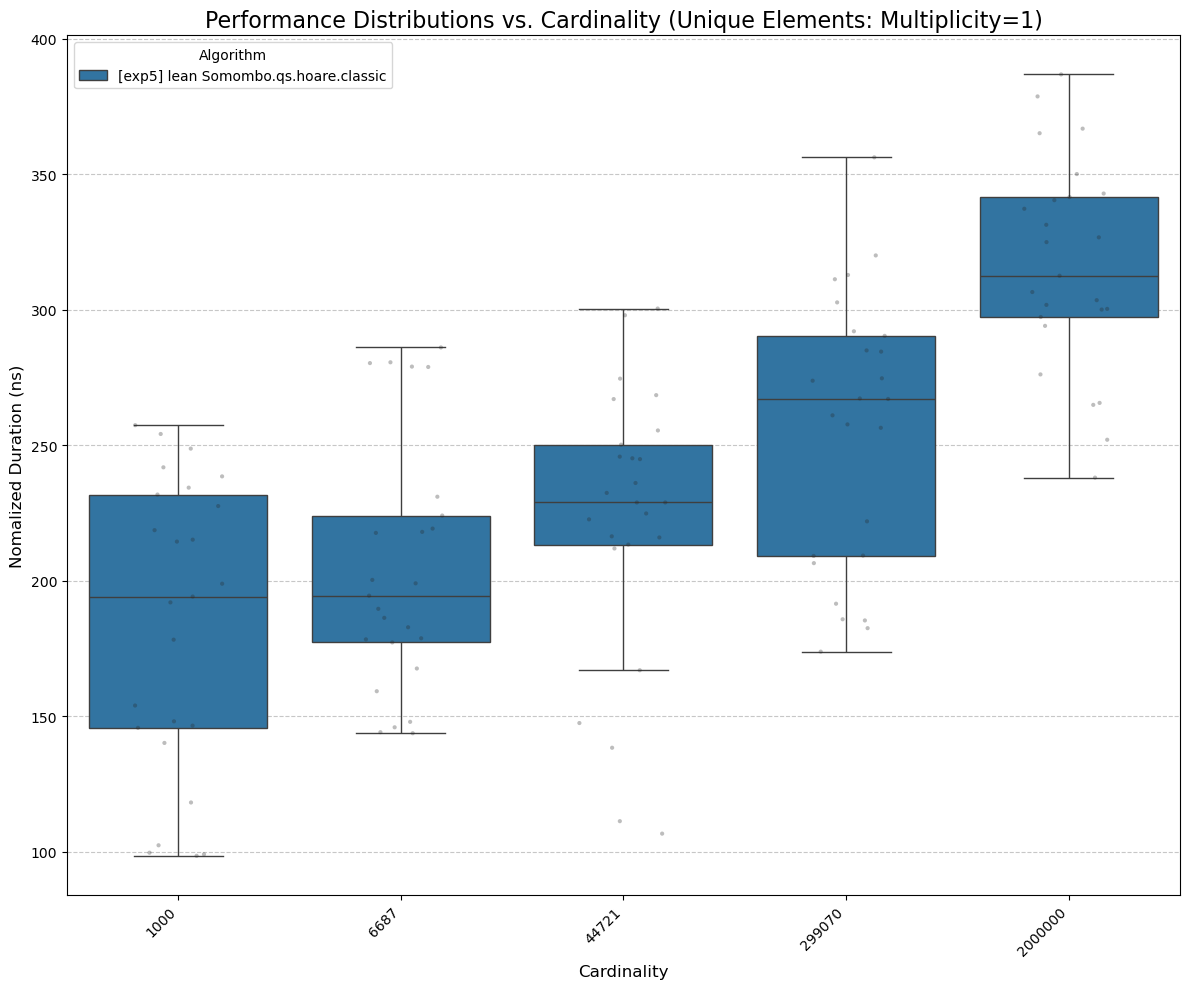

In [21]:
exp5.plot_distributions(
  'cardinality', 
  title=f'Performance Distributions vs. Cardinality (Unique Elements: Multiplicity=1)',
  normalized=True,
  ylog=False,
)

In [32]:
exp5.plot_trends_interactive(
    'cardinality', 
    f'Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1)',
    normalized=True,
    xlog=True,
    ylog=False,
)

--- Interactive Trend: Median Sort Performance vs. Cardinality (Unique Elements: Multiplicity=1) ---


## Summary

In [28]:
df_combined = pd.concat([
  exp1.get_raw_data(), 
  exp2.get_raw_data(), 
  exp3.get_raw_data(), 
  exp4.get_raw_data(), 
  exp5.get_raw_data(), 

], ignore_index=True)



In [29]:
import os
os.makedirs("../data", exist_ok=True)
df_combined.to_csv('../data/rep_run_study.csv', index=False)

In [31]:
df_combined = pd.read_csv('../data/rep_run_study.csv')

df_combined.head()

,macro_rep_id,macro_run_id,micro_rep_id,micro_run_id,data_hash,executor,args,task_str,cardinality,multiplicity,swaps,descending,seed,duration,experiment_name
0,0,0,0,0,8099982526329899207,lean,['Somombo.qs.hoare.classic'],lean Somombo.qs.hoare.classic,1000,1,NaN,False,1.684302e+19,166991,exp1
1,0,0,1,0,8099982526329899207,lean,['Somombo.qs.hoare.classic'],lean Somombo.qs.hoare.classic,1000,1,NaN,False,1.684302e+19,166130,exp1
2,0,0,2,0,8099982526329899207,lean,['Somombo.qs.hoare.classic'],lean Somombo.qs.hoare.classic,1000,1,NaN,False,1.684302e+19,153169,exp1
3,0,0,3,0,8099982526329899207,lean,['Somombo.qs.hoare.classic'],lean Somombo.qs.hoare.classic,1000,1,NaN,False,1.684302e+19,181356,exp1
4,0,0,4,0,8099982526329899207,lean,['Somombo.qs.hoare.classic'],lean Somombo.qs.hoare.classic,1000,1,NaN,False,1.684302e+19,157513,exp1
